In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from io import BytesIO
import base64
from IPython.display import display, HTML
import numpy as np
import seaborn as sns

In [3]:
df = pd.read_csv('team_atts_sp.csv',sep=',')

In [4]:
df2 = pd.read_csv('team_sp.csv',sep=',')

In [5]:
df2['team_fifa_api_id'] = df2['team_fifa_api_id'].apply(lambda x: int(x))

# fusionamos csv's

## team_atts_sp con la columna de nombre largo

In [8]:
df_fus = df.merge(df2[['team_fifa_api_id', 'team_long_name']], on='team_fifa_api_id', how='left')
pd.set_option('display.max_columns', None)

## cambiamos los NaN por '<N/A>'

In [10]:
df_fus = df_fus.fillna(pd.NA)
pd.set_option('display.max_columns', None)

## añadimos la columna al final de que año es cada fila

In [12]:
    df_fus["year"] = pd.to_datetime(df_fus["date"]).dt.year  # Extraer el año de la fecha
    all_years = set(range(df_fus["year"].min(), df_fus["year"].max() + 1))  # Determinar el rango de años

    new_rows = []  # Lista para almacenar nuevas filas
    columnas_extra = [
        "buildUpPlaySpeed", "buildUpPlaySpeedClass", "buildUpPlayDribbling", "buildUpPlayDribblingClass",
        "buildUpPlayPassing", "buildUpPlayPassingClass", "chanceCreationShootingClass", "chanceCreationPositioningClass",
        "defencePressure", "defencePressureClass", "defenceAggression", "defenceAggressionClass",
        "defenceTeamWidth", "defenceTeamWidthClass", "defenceDefenderLineClass"
    ]

    for team in df_fus["team_api_id"].unique():
        team_df = df_fus[df_fus["team_api_id"] == team]  # Filtrar equipo
        existing_years = set(team_df["year"])  # Años existentes del equipo
        missing_years = sorted(all_years - existing_years)[:6 - len(existing_years)]  # Asegurar máx. 6 filas

        # Obtener el team_fifa_api_id correcto para este equipo
        team_fifa_api_id = df_fus.loc[df_fus["team_api_id"] == team, "team_fifa_api_id"].iloc[0]

        for year in missing_years:
            new_row = {col: 0 for col in df_fus.columns if col not in ["date", "team_api_id", "team_fifa_api_id"]}  # Valores en 0
            new_row["team_api_id"] = team
            new_row["team_fifa_api_id"] = team_fifa_api_id  # Mantener el mismo valor
            new_row["date"] = f"{year}-01-01 00:00:00"  # Fecha genérica
            new_row["year"] = year  # Agregar el año auxiliar

            # Asegurar que las columnas adicionales también estén en la nueva fila
            for col in columnas_extra:
                new_row[col] = pd.NA

            new_rows.append(new_row)

    df_missing = pd.DataFrame(new_rows)  # Convertir nuevas filas en DataFrame
    df_final = pd.concat([df_fus, df_missing], ignore_index=True)  # Unir DataFrames
    #df_final = df_final.sort_values(by=["team_api_id", "year"]).drop(columns=["year"])  # Ordenar y eliminar columna auxiliar

df_final

C:\Users\marcm\AppData\Local\Temp\ipykernel_5268\925309501.py:34: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_final = pd.concat([df_fus, df_missing], ignore_index=True)  # Unir DataFrames


,id,team_fifa_api_id,team_api_id,date,buildUpPlaySpeed,buildUpPlaySpeedClass,buildUpPlayDribbling,buildUpPlayDribblingClass,buildUpPlayPassing,buildUpPlayPassingClass,buildUpPlayPositioningClass,chanceCreationPassing,chanceCreationPassingClass,chanceCreationCrossing,chanceCreationCrossingClass,chanceCreationShooting,chanceCreationShootingClass,chanceCreationPositioningClass,defencePressure,defencePressureClass,defenceAggression,defenceAggressionClass,defenceTeamWidth,defenceTeamWidthClass,defenceDefenderLineClass,team_long_name,year
0,40,1861,9865,2010-02-22 00:00:00,65,Balanced,NaN,Little,45,Mixed,Organised,45,Normal,45,Normal,70,Lots,Organised,70,High,65,Press,30,Narrow,Cover,UD Almería,2010
1,41,1861,9865,2011-02-22 00:00:00,55,Balanced,NaN,Little,53,Mixed,Organised,57,Normal,54,Normal,69,Lots,Organised,58,Medium,68,Double,67,Wide,Cover,UD Almería,2011
2,42,1861,9865,2012-02-22 00:00:00,42,Balanced,NaN,Little,70,Long,Organised,57,Normal,54,Normal,40,Normal,Organised,37,Medium,53,Press,45,Normal,Cover,UD Almería,2012
3,43,1861,9865,2013-09-20 00:00:00,46,Balanced,NaN,Little,65,Mixed,Organised,57,Normal,54,Normal,40,Normal,Organised,37,Medium,53,Press,45,Normal,Cover,UD Almería,2013
4,44,1861,9865,2014-09-19 00:00:00,46,Balanced,41.0,Normal,65,Mixed,Organised,57,Normal,54,Normal,40,Normal,Organised,37,Medium,53,Press,45,Normal,Cover,UD Almería,2014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,0,456,8696,2014-01-01 00:00:00,<NA>,NaN,NaN,NaN,<NA>,NaN,0,0,0,0,0,0,NaN,NaN,<NA>,NaN,<NA>,NaN,<NA>,NaN,NaN,0,2014
194,0,260,9867,2012-01-01 00:00:00,<NA>,NaN,NaN,NaN,<NA>,NaN,0,0,0,0,0,0,NaN,NaN,<NA>,NaN,<NA>,NaN,<NA>,NaN,NaN,0,2012
195,0,260,9867,2013-01-01 00:00:00,<NA>,NaN,NaN,NaN,<NA>,NaN,0,0,0,0,0,0,NaN,NaN,<NA>,NaN,<NA>,NaN,<NA>,NaN,NaN,0,2013
196,0,1742,9868,2014-01-01 00:00:00,<NA>,NaN,NaN,NaN,<NA>,NaN,0,0,0,0,0,0,NaN,NaN,<NA>,NaN,<NA>,NaN,<NA>,NaN,NaN,0,2014


## team_atts_sp con el groupby hecho

In [14]:
df_grb = df_final.groupby('team_fifa_api_id').agg(list)


# team_atts_sp dejado bonito

In [16]:
df_grb['team_api_id'] = df_grb['team_api_id'].apply(lambda x: x[0])
df_grb['team_long_name'] = df_grb['team_long_name'].apply(lambda x: x[0])

In [17]:
s = df_grb['team_long_name']

In [18]:
df_grb = df_grb.drop(columns = ['team_long_name'])
df_grb.insert(0,'team_long_name', s)

# team_atts_sp con las columnas por temporada

In [20]:
# Crear DataFrame de ejemplo con múltiples columnas con listas

df = df_grb[['buildUpPlaySpeed','buildUpPlaySpeedClass','buildUpPlayDribbling','buildUpPlayDribblingClass','buildUpPlayPassing','buildUpPlayPassingClass','buildUpPlayPositioningClass','chanceCreationPassing','chanceCreationPassingClass','chanceCreationCrossing','chanceCreationCrossingClass','chanceCreationShooting','chanceCreationShootingClass','chanceCreationPositioningClass','defencePressure','defencePressureClass','defenceAggression','defenceAggressionClass','defenceTeamWidth','defenceTeamWidthClass','defenceDefenderLineClass']]

# Identificar columnas que contienen listas
columns_to_expand = list(df.columns)#[col for col in df.columns if isinstance(df[col][0], list)]

# Definir nombres de temporadas
temporadas = ["TEMPORADA 09/10", "TEMPORADA 10/11", "TEMPORADA 11/12",
              "TEMPORADA 12/13", "TEMPORADA 13/14", "TEMPORADA 14/15"]

# Función para obtener iniciales en mayúsculas
def obtener_iniciales(nombre):
    a = nombre[0].upper()
    for i in nombre:
        if  i.isupper():
            a = a+i
    return a

# Expandir todas las columnas con listas
#df_reordenado = pd.DataFrame()
#for col in df.columns:
#    df_reordenado[col] = df[col]
#    for col in columns_to_expand:
#        df_expanded = df[col].apply(pd.Series)  # Expande la lista en columnas separadas
#        iniciales = obtener_iniciales(col)  # Obtener iniciales en mayúsculas
#        df_expanded.columns = [f"{iniciales}-{temporadas[i]}" for i in range(df_expanded.shape[1])]  # Renombrar columnas
#        df_final = pd.concat([df_reordenado, df_expanded], axis=1)

# Crear un nuevo DataFrame con el orden correcto
df_reordenado = pd.DataFrame()

# Iterar sobre las columnas del DataFrame original
for col in df.columns:
    df_reordenado[col] = df[col]  # Mantener la columna original
    if col in columns_to_expand:  # Si la columna contiene listas, expandir
        df_expanded = df[col].apply(pd.Series)  # Expandir lista en columnas
        iniciales = obtener_iniciales(col)  # Obtener iniciales
        df_expanded.columns = [f"{iniciales}-{temporadas[i]}" for i in range(df_expanded.shape[1])]  # Renombrar
        df_reordenado = pd.concat([df_reordenado, df_expanded], axis=1)  # Insertar después de la columna original

# Mostrar el resultado
pd.set_option('display.max_columns', None)

#df_reordenado.replace(0,'<N/A>')

## añadimos ahora las columnas de nombre largo y el api id

In [22]:
df_reordenado.insert(0,'team_long_name', s)
df_reordenado.insert(1,'team_api_id', df_grb['team_api_id'])
df_f = df_reordenado
df_f

,team_long_name,team_api_id,buildUpPlaySpeed,BUPS-TEMPORADA 09/10,BUPS-TEMPORADA 10/11,BUPS-TEMPORADA 11/12,BUPS-TEMPORADA 12/13,BUPS-TEMPORADA 13/14,BUPS-TEMPORADA 14/15,buildUpPlaySpeedClass,BUPSC-TEMPORADA 09/10,BUPSC-TEMPORADA 10/11,BUPSC-TEMPORADA 11/12,BUPSC-TEMPORADA 12/13,BUPSC-TEMPORADA 13/14,BUPSC-TEMPORADA 14/15,buildUpPlayDribbling,BUPD-TEMPORADA 09/10,BUPD-TEMPORADA 10/11,BUPD-TEMPORADA 11/12,BUPD-TEMPORADA 12/13,BUPD-TEMPORADA 13/14,BUPD-TEMPORADA 14/15,buildUpPlayDribblingClass,BUPDC-TEMPORADA 09/10,BUPDC-TEMPORADA 10/11,BUPDC-TEMPORADA 11/12,BUPDC-TEMPORADA 12/13,BUPDC-TEMPORADA 13/14,BUPDC-TEMPORADA 14/15,buildUpPlayPassing,BUPP-TEMPORADA 09/10,BUPP-TEMPORADA 10/11,BUPP-TEMPORADA 11/12,BUPP-TEMPORADA 12/13,BUPP-TEMPORADA 13/14,BUPP-TEMPORADA 14/15,buildUpPlayPassingClass,BUPPC-TEMPORADA 09/10,BUPPC-TEMPORADA 10/11,BUPPC-TEMPORADA 11/12,BUPPC-TEMPORADA 12/13,BUPPC-TEMPORADA 13/14,BUPPC-TEMPORADA 14/15,buildUpPlayPositioningClass,BUPPC-TEMPORADA 09/10,BUPPC-TEMPORADA 10/11,BUPPC-TEMPORADA 11/12,BUPPC-TEMPORADA 12/13,BUPPC-TEMPORADA 13/14,BUPPC-TEMPORADA 14/15,chanceCreationPassing,CCP-TEMPORADA 09/10,CCP-TEMPORADA 10/11,CCP-TEMPORADA 11/12,CCP-TEMPORADA 12/13,CCP-TEMPORADA 13/14,CCP-TEMPORADA 14/15,chanceCreationPassingClass,CCPC-TEMPORADA 09/10,CCPC-TEMPORADA 10/11,CCPC-TEMPORADA 11/12,CCPC-TEMPORADA 12/13,CCPC-TEMPORADA 13/14,CCPC-TEMPORADA 14/15,chanceCreationCrossing,CCC-TEMPORADA 09/10,CCC-TEMPORADA 10/11,CCC-TEMPORADA 11/12,CCC-TEMPORADA 12/13,CCC-TEMPORADA 13/14,CCC-TEMPORADA 14/15,chanceCreationCrossingClass,CCCC-TEMPORADA 09/10,CCCC-TEMPORADA 10/11,CCCC-TEMPORADA 11/12,CCCC-TEMPORADA 12/13,CCCC-TEMPORADA 13/14,CCCC-TEMPORADA 14/15,chanceCreationShooting,CCS-TEMPORADA 09/10,CCS-TEMPORADA 10/11,CCS-TEMPORADA 11/12,CCS-TEMPORADA 12/13,CCS-TEMPORADA 13/14,CCS-TEMPORADA 14/15,chanceCreationShootingClass,CCSC-TEMPORADA 09/10,CCSC-TEMPORADA 10/11,CCSC-TEMPORADA 11/12,CCSC-TEMPORADA 12/13,CCSC-TEMPORADA 13/14,CCSC-TEMPORADA 14/15,chanceCreationPositioningClass,CCPC-TEMPORADA 09/10,CCPC-TEMPORADA 10/11,CCPC-TEMPORADA 11/12,CCPC-TEMPORADA 12/13,CCPC-TEMPORADA 13/14,CCPC-TEMPORADA 14/15,defencePressure,DP-TEMPORADA 09/10,DP-TEMPORADA 10/11,DP-TEMPORADA 11/12,DP-TEMPORADA 12/13,DP-TEMPORADA 13/14,DP-TEMPORADA 14/15,defencePressureClass,DPC-TEMPORADA 09/10,DPC-TEMPORADA 10/11,DPC-TEMPORADA 11/12,DPC-TEMPORADA 12/13,DPC-TEMPORADA 13/14,DPC-TEMPORADA 14/15,defenceAggression,DA-TEMPORADA 09/10,DA-TEMPORADA 10/11,DA-TEMPORADA 11/12,DA-TEMPORADA 12/13,DA-TEMPORADA 13/14,DA-TEMPORADA 14/15,defenceAggressionClass,DAC-TEMPORADA 09/10,DAC-TEMPORADA 10/11,DAC-TEMPORADA 11/12,DAC-TEMPORADA 12/13,DAC-TEMPORADA 13/14,DAC-TEMPORADA 14/15,defenceTeamWidth,DTW-TEMPORADA 09/10,DTW-TEMPORADA 10/11,DTW-TEMPORADA 11/12,DTW-TEMPORADA 12/13,DTW-TEMPORADA 13/14,DTW-TEMPORADA 14/15,defenceTeamWidthClass,DTWC-TEMPORADA 09/10,DTWC-TEMPORADA 10/11,DTWC-TEMPORADA 11/12,DTWC-TEMPORADA 12/13,DTWC-TEMPORADA 13/14,DTWC-TEMPORADA 14/15,defenceDefenderLineClass,DDLC-TEMPORADA 09/10,DDLC-TEMPORADA 10/11,DDLC-TEMPORADA 11/12,DDLC-TEMPORADA 12/13,DDLC-TEMPORADA 13/14,DDLC-TEMPORADA 14/15
team_fifa_api_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
240,Atlético Madrid,9906,"[64, 57, 47, 47, 47, 57]",64,57,47,47,47,57,"[Balanced, Balanced, Balanced, Balanced, Balan...",Balanced,Balanced,Balanced,Balanced,Balanced,Balanced,"[nan, nan, nan, nan, 52.0, 50.0]",NaN,NaN,NaN,NaN,52.0,50.0,"[Little, Little, Little, Little, Normal, Normal]",Little,Little,Little,Little,Normal,Normal,"[30, 54, 51, 51, 51, 50]",30,54,51,51,51,50,"[Short, Mixed, Mixed, Mixed, Mixed, Mixed]",Short,Mixed,Mixed,Mixed,Mixed,Mixed,"[Free Form, Organised, Organised, Organised, O...",Free Form,Organised,Organised,Organised,Organised,Organised,"[65, 58, 67, 70, 67, 61]",65,58,67,70,67,61,"[Normal, Normal, Risky, Risky, Risky, Normal]",Normal,Normal,Risky,Risky,Risky,Normal,"[50, 69, 63, 6

## empezamos con los gráficos

### scatter de prueba

<Figure size 5000x2500 with 0 Axes>

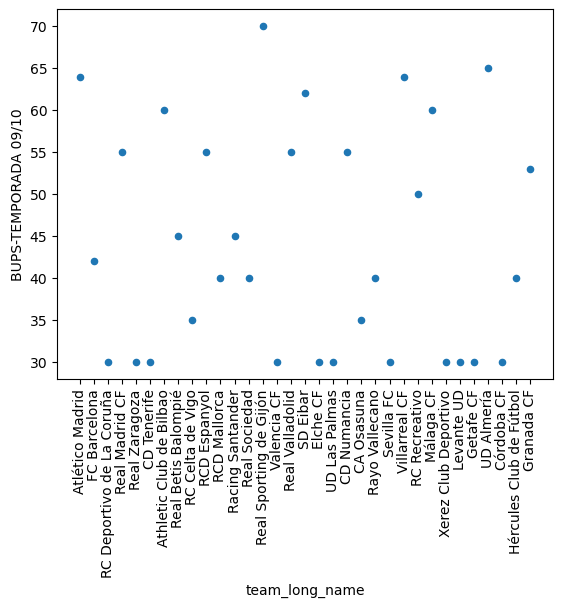

In [25]:
#https://datacarpentry.github.io/python-ecology-lesson-es/08-putting-it-all-together.html
#https://matplotlib.org/2.0.2/users/screenshots.html
#matplotlib inline
plt.figure(figsize=(50, 25))
BUPS1 = df_f.plot("team_long_name", "BUPS-TEMPORADA 09/10", kind="scatter")
plt.xticks(rotation=90)
plt.margins(x=0.05) 

## gráfico de modelo

### gráfico para todos los equipos

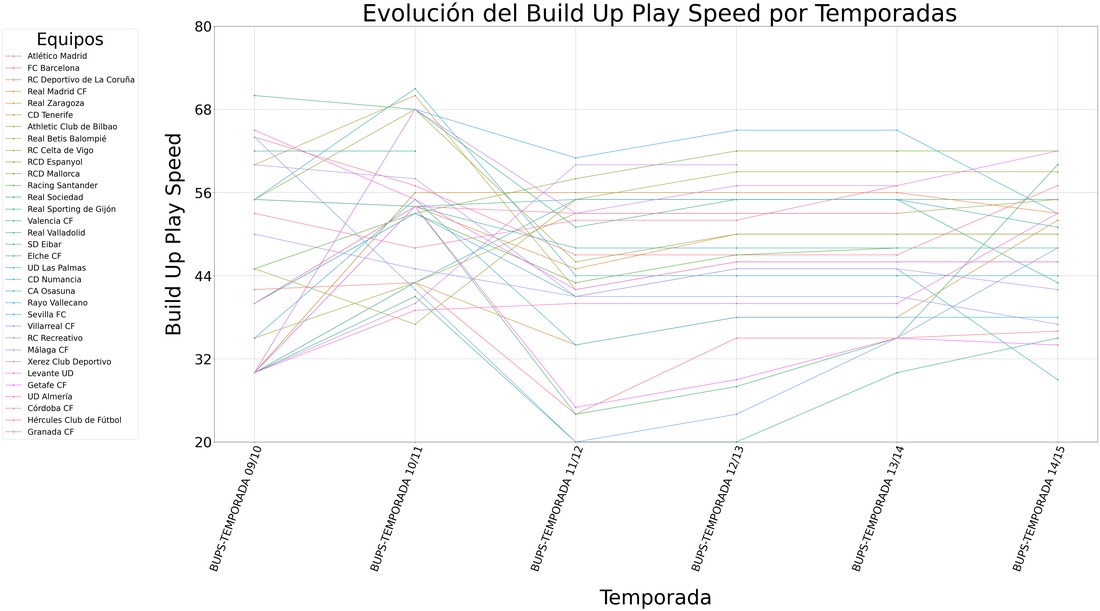

In [28]:
# ATENCIÓN CAMBIAR EL _BUPS PARA SU HOMOLOGO EN CADA DF!!!
df_bups = df_f[['team_long_name','BUPS-TEMPORADA 09/10',	'BUPS-TEMPORADA 10/11',	'BUPS-TEMPORADA 11/12',	'BUPS-TEMPORADA 12/13',	'BUPS-TEMPORADA 13/14',	'BUPS-TEMPORADA 14/15']]


# Suponiendo que df_f tiene equipos como filas y años como columnas
# Convertir el DataFrame a formato largo
df_bups2 = df_bups.melt(id_vars=["team_long_name"], var_name="Temporada", value_name="Valor") #["team_long_name"]

# Crear el gráfico de líneas
plt.figure(figsize=(50, 25))
bups = sns.lineplot(data=df_bups2, x="Temporada", y="Valor", hue="team_long_name", marker="o")

# Personalizar gráfico
plt.xlabel("Temporada",fontsize=64,labelpad = 50)
plt.ylabel("Build Up Play Speed",fontsize=64,labelpad = 30)
#Toquetear el eje y
bups.invert_yaxis()
# Definir rango del eje Y
plt.ylim(20, 80)

# Número de divisiones deseado
num_divisiones = 6  

# Generar los valores de las marcas (ticks)
yticks = np.linspace(20, 80, num_divisiones)  

# Aplicar las marcas al eje Y
plt.yticks(yticks)
plt.title(" Evolución del Build Up Play Speed por Temporadas",fontsize=74)
plt.legend(title="Equipos",fontsize=25,title_fontsize=54, loc="center left", bbox_to_anchor=(-0.24,0.5),borderaxespad=0.)
plt.xticks(fontsize=34,rotation=70,ha = 'right',rotation_mode='anchor') # Rotar etiquetas si hay muchos años
plt.yticks(fontsize=44,rotation=0)
plt.subplots_adjust(bottom=0.15)
#plt.margins(x=0.4)
#plt.subplots_adjust(left=0.05, right=0.75)
plt.grid(True)

### gráfico para un solo equipo

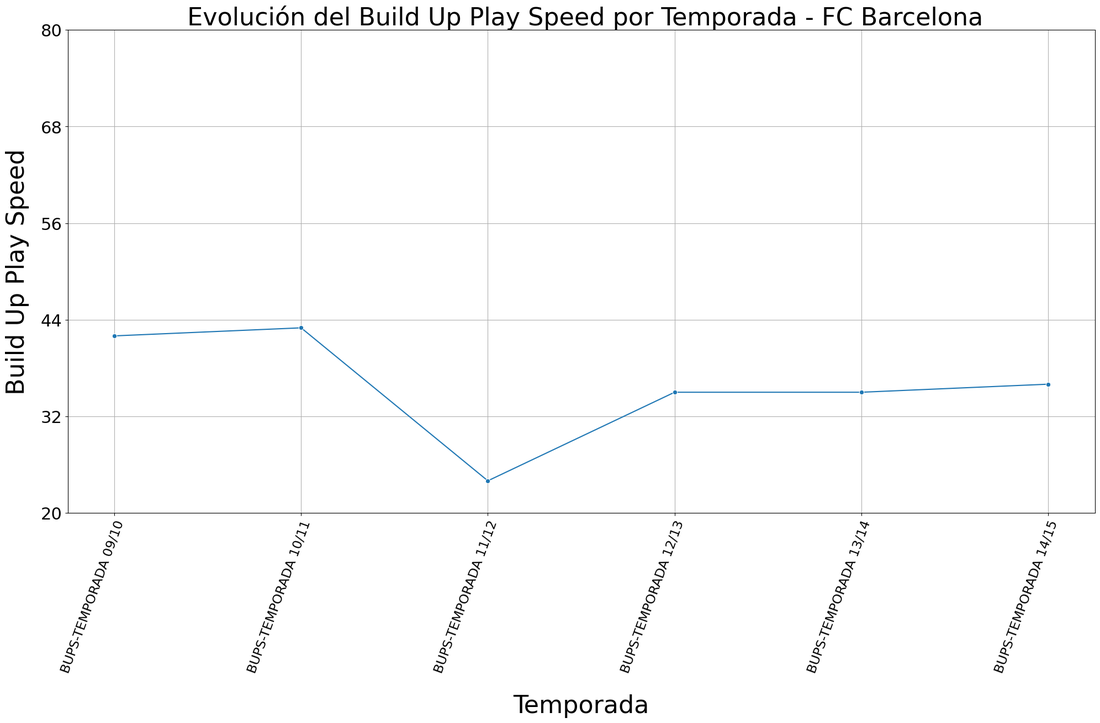

In [30]:
df_bups = df_f[['team_long_name','BUPS-TEMPORADA 09/10',	'BUPS-TEMPORADA 10/11',	'BUPS-TEMPORADA 11/12',	'BUPS-TEMPORADA 12/13',	'BUPS-TEMPORADA 13/14',	'BUPS-TEMPORADA 14/15']]
# Escoger de que equipo hacer el gráfico
equipo_especifico = "FC Barcelona"
df_bups = df_f[['team_long_name', 'BUPS-TEMPORADA 09/10', 'BUPS-TEMPORADA 10/11', 'BUPS-TEMPORADA 11/12',
                 'BUPS-TEMPORADA 12/13', 'BUPS-TEMPORADA 13/14', 'BUPS-TEMPORADA 14/15']]

df_bups = df_bups[df_bups["team_long_name"] == equipo_especifico]  # Filtra solo un equipo

# Suponiendo que df_f tiene equipos como filas y años como columnas
# Convertir el DataFrame a formato largo
df_bups2 = df_bups.melt(id_vars=["team_long_name"], var_name="Temporada", value_name="Valor") #["team_long_name"]

# Crear el gráfico de líneas
plt.figure(figsize=(24, 12))
bups = sns.lineplot(data=df_bups2, x="Temporada", y="Valor", marker="o")

# Personalizar gráfico
plt.xlabel("Temporada",fontsize=32,labelpad = 25)
plt.ylabel("Build Up Play Speed",fontsize=32,labelpad = 15)

# ESTO SOLO PARA LOS GRÁFICOS NUMÉRICOS, PARA LOS DE PALABRAS ELIMINAR TODO MENOS EL INVERT
#Toquetear el eje y
#bups.invert_yaxis()
# Definir rango del eje Y
plt.ylim(20, 80)

# Número de divisiones deseado
num_divisiones = 6  

# Generar los valores de las marcas (ticks)
yticks = np.linspace(20, 80, num_divisiones)  

# Aplicar las marcas al eje Y
plt.yticks(yticks)

plt.title(" Evolución del Build Up Play Speed por Temporada - FC Barcelona",fontsize=32)
# plt.legend(title="Equipos",fontsize=25,title_fontsize=54, loc="center left", bbox_to_anchor=(-0.24,0.5),borderaxespad=0.)
plt.xticks(fontsize=17,rotation=70,ha = 'right',rotation_mode='anchor') # Rotar etiquetas si hay muchos años
plt.yticks(fontsize=22,rotation=0)
plt.subplots_adjust(bottom=0.15)
#plt.margins(x=0.4)
#plt.subplots_adjust(left=0.05, right=0.75)
plt.grid(True)


## GRÁFICOS DEL FC BARCELONA

### GRÁFICO BUPS

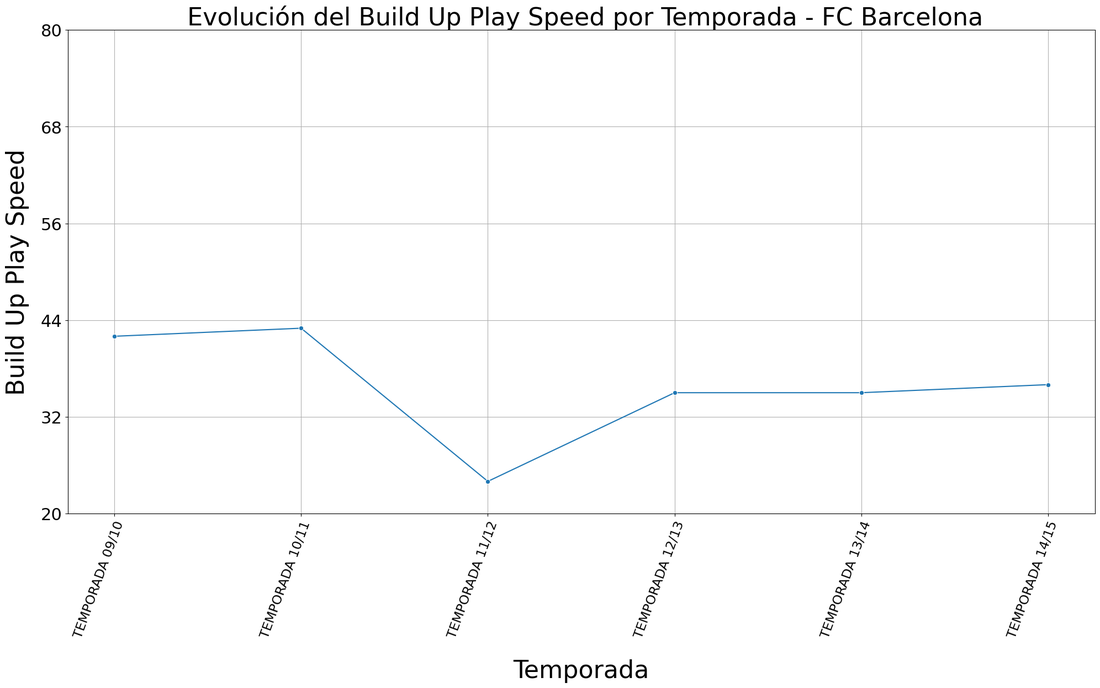

In [33]:
# Escoger de que equipo hacer el gráfico
equipo_especifico = "FC Barcelona"
df_bups = df_f[['team_long_name', 'BUPS-TEMPORADA 09/10', 'BUPS-TEMPORADA 10/11', 'BUPS-TEMPORADA 11/12',
                 'BUPS-TEMPORADA 12/13', 'BUPS-TEMPORADA 13/14', 'BUPS-TEMPORADA 14/15']]

df_bups = df_bups[df_bups["team_long_name"] == equipo_especifico]  # Filtra solo un equipo

# Suponiendo que df_f tiene equipos como filas y años como columnas
# Convertir el DataFrame a formato largo
df_bups2 = df_bups.melt(id_vars=["team_long_name"], var_name="Temporada", value_name="Valor") #["team_long_name"]

# Crear el gráfico de líneas
plt.figure(figsize=(24, 12))
bups = sns.lineplot(data=df_bups2, x="Temporada", y="Valor", marker="o")

# Personalizar gráfico
plt.xlabel("Temporada",fontsize=32,labelpad = 25)
plt.ylabel("Build Up Play Speed",fontsize=32,labelpad = 15)

# ESTO SOLO PARA LOS GRÁFICOS NUMÉRICOS, PARA LOS DE PALABRAS ELIMINAR TODO MENOS EL INVERT
#Toquetear el eje y
#bupsc.invert_yaxis()
# Definir rango del eje Y
plt.ylim(20, 80)

# Número de divisiones deseado
num_divisiones = 6  

# Generar los valores de las marcas (ticks)
yticks = np.linspace(20, 80, num_divisiones)  

# Aplicar las marcas al eje Y
plt.yticks(yticks)

plt.title(" Evolución del Build Up Play Speed por Temporada - FC Barcelona",fontsize=32)
# plt.legend(title="Equipos",fontsize=25,title_fontsize=54, loc="center left", bbox_to_anchor=(-0.24,0.5),borderaxespad=0.)

plt.xticks(fontsize=17,rotation=70,ha = 'right',rotation_mode='anchor') # Rotar etiquetas si hay muchos años
nombres_personalizados = ["TEMPORADA 09/10", "TEMPORADA 10/11", "TEMPORADA 11/12", "TEMPORADA 12/13", "TEMPORADA 13/14", "TEMPORADA 14/15"]
plt.xticks(ticks=range(len(nombres_personalizados)), labels=nombres_personalizados)

plt.yticks(fontsize=22,rotation=0)

plt.subplots_adjust(bottom=0.15)
#plt.margins(x=0.4)
#plt.subplots_adjust(left=0.05, right=0.75)
plt.grid(True)

### GRÁFICO BUPP

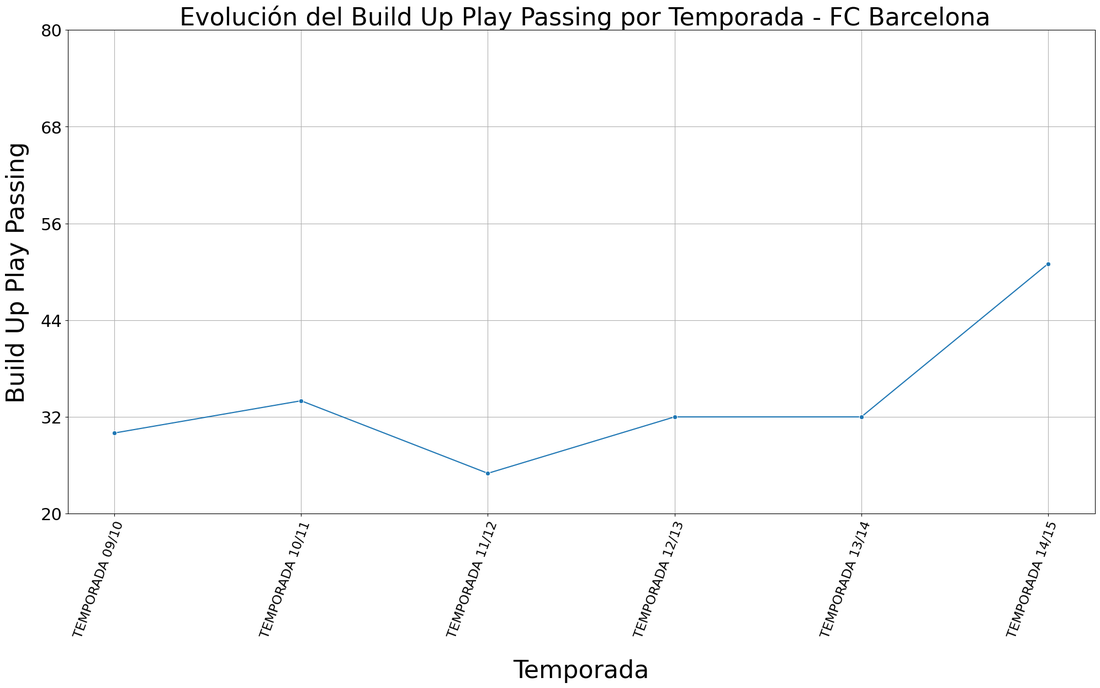

In [35]:
df_bupp = df_f[['team_long_name','BUPP-TEMPORADA 09/10',	'BUPP-TEMPORADA 10/11',	'BUPP-TEMPORADA 11/12',	'BUPP-TEMPORADA 12/13',	'BUPP-TEMPORADA 13/14',	'BUPP-TEMPORADA 14/15']]
# Escoger de que equipo hacer el gráfico
equipo_especifico = "FC Barcelona"
df_bupp = df_f[['team_long_name', 'BUPP-TEMPORADA 09/10', 'BUPP-TEMPORADA 10/11', 'BUPP-TEMPORADA 11/12',
                 'BUPP-TEMPORADA 12/13', 'BUPP-TEMPORADA 13/14', 'BUPP-TEMPORADA 14/15']]

df_bupp= df_bupp[df_bupp["team_long_name"] == equipo_especifico]  # Filtra solo un equipo

# Suponiendo que df_f tiene equipos como filas y años como columnas
# Convertir el DataFrame a formato largo
df_bupp2 = df_bupp.melt(id_vars=["team_long_name"], var_name="Temporada", value_name="Valor") #["team_long_name"]

# Crear el gráfico de líneas
plt.figure(figsize=(24, 12))
bupp = sns.lineplot(data=df_bupp2, x="Temporada", y="Valor", marker="o")

# Personalizar gráfico
plt.xlabel("Temporada",fontsize=32,labelpad = 25)
plt.ylabel("Build Up Play Passing",fontsize=32,labelpad = 15)

# ESTO SOLO PARA LOS GRÁFICOS NUMÉRICOS, PARA LOS DE PALABRAS ELIMINAR TODO MENOS EL INVERT
#Toquetear el eje y
#bupp.invert_yaxis()
# Definir rango del eje Y
plt.ylim(20, 80)

# Número de divisiones deseado
num_divisiones = 6  

# Generar los valores de las marcas (ticks)
yticks = np.linspace(20, 80, num_divisiones)  

# Aplicar las marcas al eje Y
plt.yticks(yticks)

plt.title(" Evolución del Build Up Play Passing por Temporada - FC Barcelona",fontsize=32)
# plt.legend(title="Equipos",fontsize=25,title_fontsize=54, loc="center left", bbox_to_anchor=(-0.24,0.5),borderaxespad=0.)

plt.xticks(fontsize=17,rotation=70,ha = 'right',rotation_mode='anchor') # Rotar etiquetas si hay muchos años
nombres_personalizados = ["TEMPORADA 09/10", "TEMPORADA 10/11", "TEMPORADA 11/12", "TEMPORADA 12/13", "TEMPORADA 13/14", "TEMPORADA 14/15"]
plt.xticks(ticks=range(len(nombres_personalizados)), labels=nombres_personalizados)

plt.yticks(fontsize=22,rotation=0)
plt.subplots_adjust(bottom=0.15)
#plt.margins(x=0.4)
#plt.subplots_adjust(left=0.05, right=0.75)
plt.grid(True)

### GRÁFICO CCP

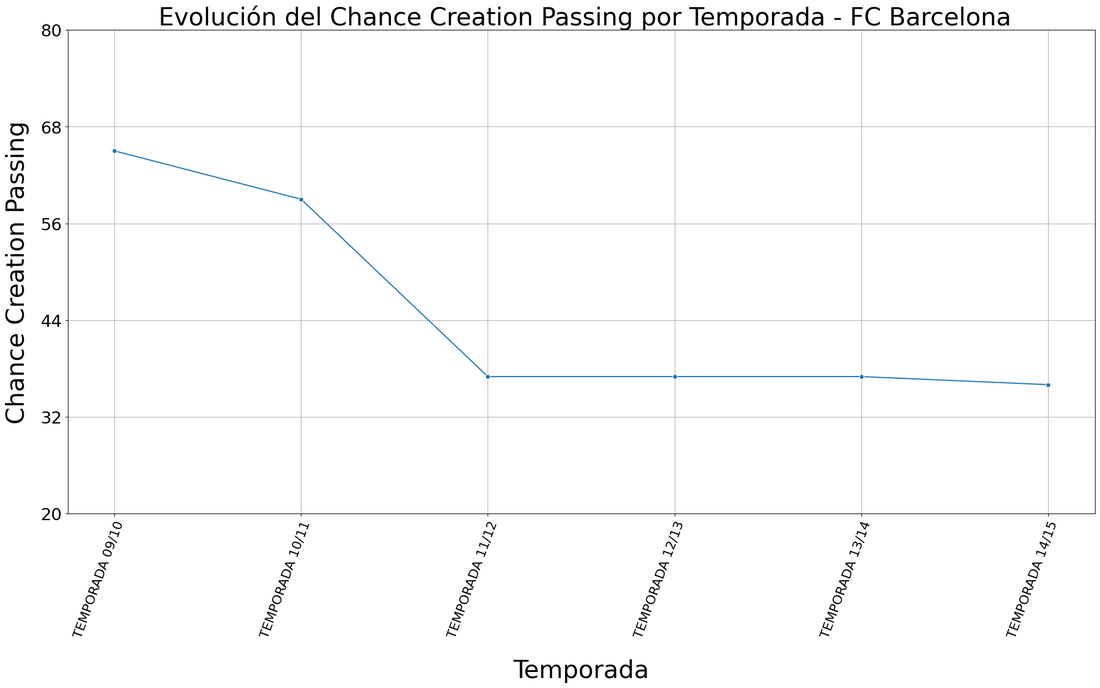

In [37]:
df_ccp = df_f[['team_long_name','CCP-TEMPORADA 09/10',	'CCP-TEMPORADA 10/11',	'CCP-TEMPORADA 11/12',	'CCP-TEMPORADA 12/13',	'CCP-TEMPORADA 13/14',	'CCP-TEMPORADA 14/15']]
# Escoger de que equipo hacer el gráfico
equipo_especifico = "FC Barcelona"
df_ccp = df_f[['team_long_name', 'CCP-TEMPORADA 09/10', 'CCP-TEMPORADA 10/11', 'CCP-TEMPORADA 11/12',
                 'CCP-TEMPORADA 12/13', 'CCP-TEMPORADA 13/14', 'CCP-TEMPORADA 14/15']]

df_ccp= df_ccp[df_ccp["team_long_name"] == equipo_especifico]  # Filtra solo un equipo

# Suponiendo que df_f tiene equipos como filas y años como columnas
# Convertir el DataFrame a formato largo
df_ccp2 = df_ccp.melt(id_vars=["team_long_name"], var_name="Temporada", value_name="Valor") #["team_long_name"]

# Crear el gráfico de líneas
plt.figure(figsize=(24, 12))
ccp = sns.lineplot(data=df_ccp2, x="Temporada", y="Valor", marker="o")

# Personalizar gráfico
plt.xlabel("Temporada",fontsize=32,labelpad = 25)
plt.ylabel("Chance Creation Passing",fontsize=32,labelpad = 15)

# ESTO SOLO PARA LOS GRÁFICOS NUMÉRICOS, PARA LOS DE PALABRAS ELIMINAR TODO MENOS EL INVERT
#Toquetear el eje y
#ccp.invert_yaxis()
# Definir rango del eje Y
plt.ylim(20, 80)

# Número de divisiones deseado
num_divisiones = 6  

# Generar los valores de las marcas (ticks)
yticks = np.linspace(20, 80, num_divisiones)  

# Aplicar las marcas al eje Y
plt.yticks(yticks)

plt.title(" Evolución del Chance Creation Passing por Temporada - FC Barcelona",fontsize=32)
# plt.legend(title="Equipos",fontsize=25,title_fontsize=54, loc="center left", bbox_to_anchor=(-0.24,0.5),borderaxespad=0.)

plt.xticks(fontsize=17,rotation=70,ha = 'right',rotation_mode='anchor') # Rotar etiquetas si hay muchos años
nombres_personalizados = ["TEMPORADA 09/10", "TEMPORADA 10/11", "TEMPORADA 11/12", "TEMPORADA 12/13", "TEMPORADA 13/14", "TEMPORADA 14/15"]
plt.xticks(ticks=range(len(nombres_personalizados)), labels=nombres_personalizados)

plt.yticks(fontsize=22,rotation=0)
plt.subplots_adjust(bottom=0.15)
#plt.margins(x=0.4)
#plt.subplots_adjust(left=0.05, right=0.75)
plt.grid(True)

### GRÁFICO CCC

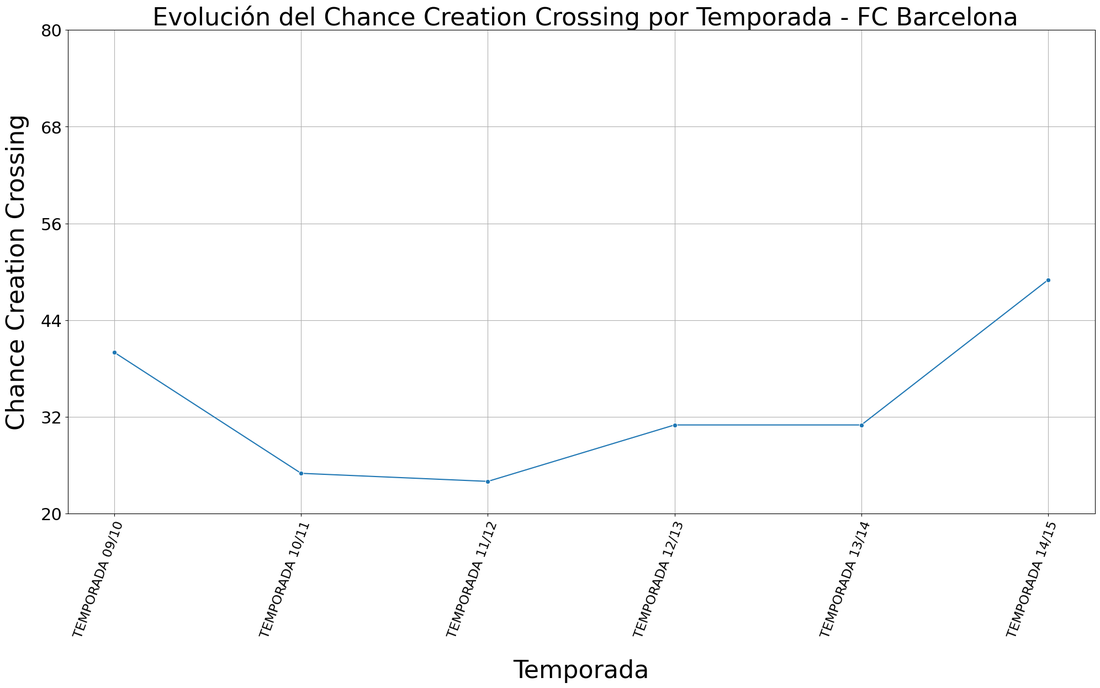

In [39]:
df_ccc = df_f[['team_long_name','CCC-TEMPORADA 09/10',	'CCC-TEMPORADA 10/11',	'CCC-TEMPORADA 11/12',	'CCC-TEMPORADA 12/13',	'CCC-TEMPORADA 13/14',	'CCC-TEMPORADA 14/15']]
# Escoger de que equipo hacer el gráfico
equipo_especifico = "FC Barcelona"
df_ccc = df_f[['team_long_name', 'CCC-TEMPORADA 09/10', 'CCC-TEMPORADA 10/11', 'CCC-TEMPORADA 11/12',
                 'CCC-TEMPORADA 12/13', 'CCC-TEMPORADA 13/14', 'CCC-TEMPORADA 14/15']]

df_ccc= df_ccc[df_ccc["team_long_name"] == equipo_especifico]  # Filtra solo un equipo

# Suponiendo que df_f tiene equipos como filas y años como columnas
# Convertir el DataFrame a formato largo
df_ccc2 = df_ccc.melt(id_vars=["team_long_name"], var_name="Temporada", value_name="Valor") #["team_long_name"]

# Crear el gráfico de líneas
plt.figure(figsize=(24, 12))
ccc = sns.lineplot(data=df_ccc2, x="Temporada", y="Valor", marker="o")

# Personalizar gráfico
plt.xlabel("Temporada",fontsize=32,labelpad = 25)
plt.ylabel("Chance Creation Crossing",fontsize=32,labelpad = 15)

# ESTO SOLO PARA LOS GRÁFICOS NUMÉRICOS, PARA LOS DE PALABRAS ELIMINAR TODO MENOS EL INVERT
#Toquetear el eje y
#ccc.invert_yaxis()
# Definir rango del eje Y
plt.ylim(20, 80)

# Número de divisiones deseado
num_divisiones = 6  

# Generar los valores de las marcas (ticks)
yticks = np.linspace(20, 80, num_divisiones)  

# Aplicar las marcas al eje Y
plt.yticks(yticks)

plt.title(" Evolución del Chance Creation Crossing por Temporada - FC Barcelona",fontsize=32)
# plt.legend(title="Equipos",fontsize=25,title_fontsize=54, loc="center left", bbox_to_anchor=(-0.24,0.5),borderaxespad=0.)

plt.xticks(fontsize=17,rotation=70,ha = 'right',rotation_mode='anchor') # Rotar etiquetas si hay muchos años
nombres_personalizados = ["TEMPORADA 09/10", "TEMPORADA 10/11", "TEMPORADA 11/12", "TEMPORADA 12/13", "TEMPORADA 13/14", "TEMPORADA 14/15"]
plt.xticks(ticks=range(len(nombres_personalizados)), labels=nombres_personalizados)

plt.yticks(fontsize=22,rotation=0)
plt.subplots_adjust(bottom=0.15)
#plt.margins(x=0.4)
#plt.subplots_adjust(left=0.05, right=0.75)
plt.grid(True)

### GRÁFICO CCS

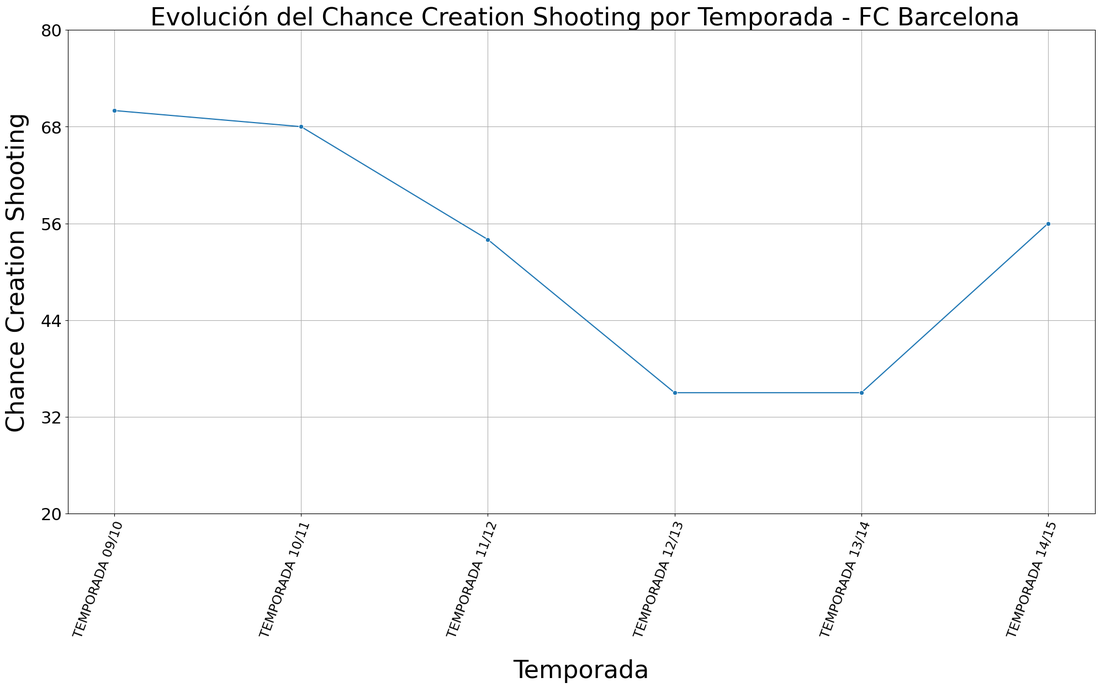

In [41]:
df_ccs = df_f[['team_long_name','CCS-TEMPORADA 09/10',	'CCS-TEMPORADA 10/11',	'CCS-TEMPORADA 11/12',	'CCS-TEMPORADA 12/13',	'CCS-TEMPORADA 13/14',	'CCS-TEMPORADA 14/15']]

# Escoger de que equipo hacer el gráfico
equipo_especifico = "FC Barcelona"
df_ccs = df_f[['team_long_name', 'CCS-TEMPORADA 09/10', 'CCS-TEMPORADA 10/11', 'CCS-TEMPORADA 11/12',
                 'CCS-TEMPORADA 12/13', 'CCS-TEMPORADA 13/14', 'CCS-TEMPORADA 14/15']]

df_ccs= df_ccs[df_ccs["team_long_name"] == equipo_especifico]  # Filtra solo un equipo

# Suponiendo que df_f tiene equipos como filas y años como columnas
# Convertir el DataFrame a formato largo
df_ccs2 = df_ccs.melt(id_vars=["team_long_name"], var_name="Temporada", value_name="Valor") #["team_long_name"]

# Crear el gráfico de líneas
plt.figure(figsize=(24, 12))
ccs = sns.lineplot(data=df_ccs2, x="Temporada", y="Valor", marker="o")

# Personalizar gráfico
plt.xlabel("Temporada",fontsize=32,labelpad = 25)
plt.ylabel("Chance Creation Shooting",fontsize=32,labelpad = 15)

# ESTO SOLO PARA LOS GRÁFICOS NUMÉRICOS, PARA LOS DE PALABRAS ELIMINAR TODO MENOS EL INVERT
#Toquetear el eje y
#ccs.invert_yaxis()
# Definir rango del eje Y
plt.ylim(20, 80)

# Número de divisiones deseado
num_divisiones = 6  

# Generar los valores de las marcas (ticks)
yticks = np.linspace(20, 80, num_divisiones)  

# Aplicar las marcas al eje Y
plt.yticks(yticks)

plt.title(" Evolución del Chance Creation Shooting por Temporada - FC Barcelona",fontsize=32)
# plt.legend(title="Equipos",fontsize=25,title_fontsize=54, loc="center left", bbox_to_anchor=(-0.24,0.5),borderaxespad=0.)

plt.xticks(fontsize=17,rotation=70,ha = 'right',rotation_mode='anchor') # Rotar etiquetas si hay muchos años
nombres_personalizados = ["TEMPORADA 09/10", "TEMPORADA 10/11", "TEMPORADA 11/12", "TEMPORADA 12/13", "TEMPORADA 13/14", "TEMPORADA 14/15"]
plt.xticks(ticks=range(len(nombres_personalizados)), labels=nombres_personalizados)

plt.yticks(fontsize=22,rotation=0)
plt.subplots_adjust(bottom=0.15)
#plt.margins(x=0.4)
#plt.subplots_adjust(left=0.05, right=0.75)
plt.grid(True)

### GRÁFICO DP

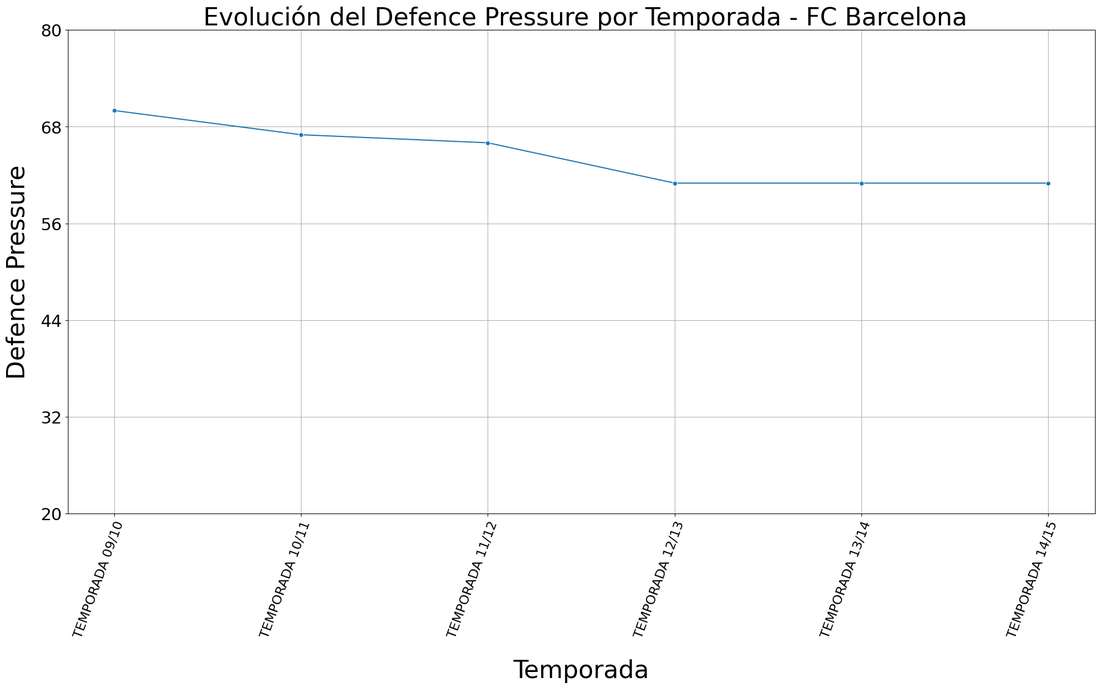

In [43]:
df_dp = df_f[['team_long_name','DP-TEMPORADA 09/10',	'DP-TEMPORADA 10/11',	'DP-TEMPORADA 11/12',	'DP-TEMPORADA 12/13',	'DP-TEMPORADA 13/14',	'DP-TEMPORADA 14/15']]
# Escoger de que equipo hacer el gráfico
equipo_especifico = "FC Barcelona"
df_dp = df_f[['team_long_name', 'DP-TEMPORADA 09/10', 'DP-TEMPORADA 10/11', 'DP-TEMPORADA 11/12',
                 'DP-TEMPORADA 12/13', 'DP-TEMPORADA 13/14', 'DP-TEMPORADA 14/15']]

df_dp= df_dp[df_dp["team_long_name"] == equipo_especifico]  # Filtra solo un equipo

# Suponiendo que df_f tiene equipos como filas y años como columnas
# Convertir el DataFrame a formato largo
df_dp2 = df_dp.melt(id_vars=["team_long_name"], var_name="Temporada", value_name="Valor") #["team_long_name"]

# Crear el gráfico de líneas
plt.figure(figsize=(24, 12))
dp = sns.lineplot(data=df_dp2, x="Temporada", y="Valor", marker="o")

# Personalizar gráfico
plt.xlabel("Temporada",fontsize=32,labelpad = 25)
plt.ylabel("Defence Pressure",fontsize=32,labelpad = 15)

# ESTO SOLO PARA LOS GRÁFICOS NUMÉRICOS, PARA LOS DE PALABRAS ELIMINAR TODO MENOS EL INVERT
#Toquetear el eje y
#dp.invert_yaxis()
# Definir rango del eje Y
plt.ylim(20, 80)

# Número de divisiones deseado
num_divisiones = 6  

# Generar los valores de las marcas (ticks)
yticks = np.linspace(20, 80, num_divisiones)  

# Aplicar las marcas al eje Y
plt.yticks(yticks)

plt.title(" Evolución del Defence Pressure por Temporada - FC Barcelona",fontsize=32)
# plt.legend(title="Equipos",fontsize=25,title_fontsize=54, loc="center left", bbox_to_anchor=(-0.24,0.5),borderaxespad=0.)

plt.xticks(fontsize=17,rotation=70,ha = 'right',rotation_mode='anchor') # Rotar etiquetas si hay muchos años
nombres_personalizados = ["TEMPORADA 09/10", "TEMPORADA 10/11", "TEMPORADA 11/12", "TEMPORADA 12/13", "TEMPORADA 13/14", "TEMPORADA 14/15"]
plt.xticks(ticks=range(len(nombres_personalizados)), labels=nombres_personalizados)

plt.yticks(fontsize=22,rotation=0)
plt.subplots_adjust(bottom=0.15)
#plt.margins(x=0.4)
#plt.subplots_adjust(left=0.05, right=0.75)
plt.grid(True)

### GRÁFICO DA

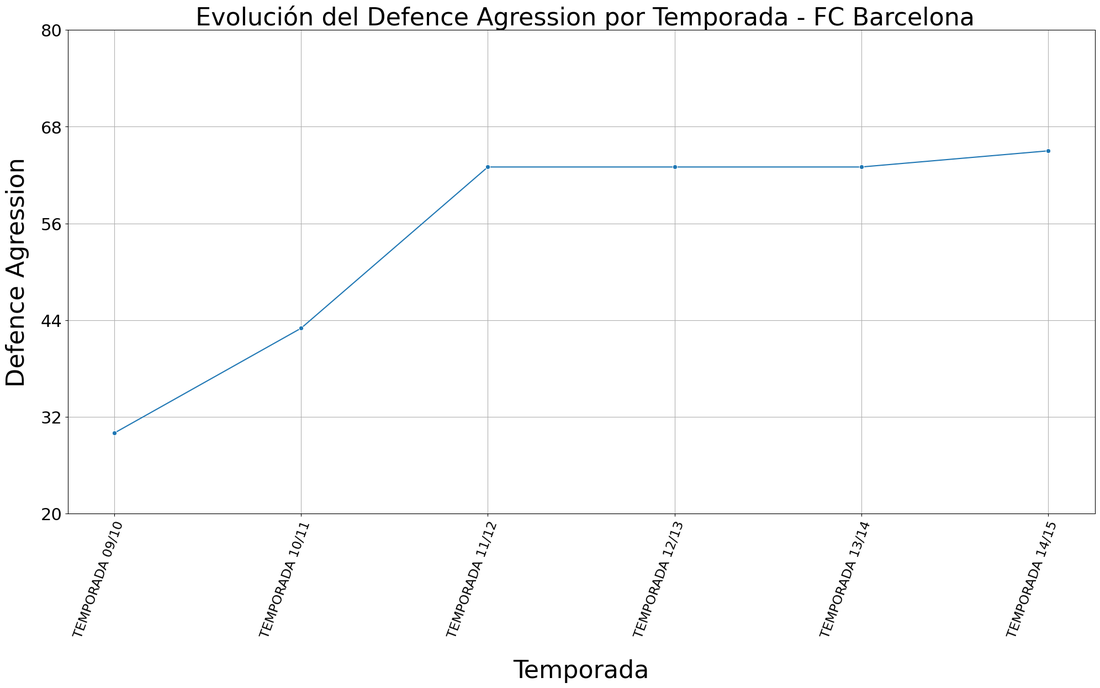

In [45]:
df_da = df_f[['team_long_name','DA-TEMPORADA 09/10',	'DA-TEMPORADA 10/11',	'DA-TEMPORADA 11/12',	'DA-TEMPORADA 12/13',	'DA-TEMPORADA 13/14',	'DA-TEMPORADA 14/15']]

# Escoger de que equipo hacer el gráfico
equipo_especifico = "FC Barcelona"
df_da = df_f[['team_long_name', 'DA-TEMPORADA 09/10', 'DA-TEMPORADA 10/11', 'DA-TEMPORADA 11/12',
                 'DA-TEMPORADA 12/13', 'DA-TEMPORADA 13/14', 'DA-TEMPORADA 14/15']]

df_da= df_da[df_da["team_long_name"] == equipo_especifico]  # Filtra solo un equipo

# Suponiendo que df_f tiene equipos como filas y años como columnas
# Convertir el DataFrame a formato largo
df_da2 = df_da.melt(id_vars=["team_long_name"], var_name="Temporada", value_name="Valor") #["team_long_name"]

# Crear el gráfico de líneas
plt.figure(figsize=(24, 12))
da = sns.lineplot(data=df_da2, x="Temporada", y="Valor", marker="o")

# Personalizar gráfico
plt.xlabel("Temporada",fontsize=32,labelpad = 25)
plt.ylabel("Defence Agression",fontsize=32,labelpad = 15)

# ESTO SOLO PARA LOS GRÁFICOS NUMÉRICOS, PARA LOS DE PALABRAS ELIMINAR TODO MENOS EL INVERT
#Toquetear el eje y
#da.invert_yaxis()
# Definir rango del eje Y
plt.ylim(20, 80)

# Número de divisiones deseado
num_divisiones = 6  

# Generar los valores de las marcas (ticks)
yticks = np.linspace(20, 80, num_divisiones)  

# Aplicar las marcas al eje Y
plt.yticks(yticks)

plt.title(" Evolución del Defence Agression por Temporada - FC Barcelona",fontsize=32)
# plt.legend(title="Equipos",fontsize=25,title_fontsize=54, loc="center left", bbox_to_anchor=(-0.24,0.5),borderaxespad=0.)

plt.xticks(fontsize=17,rotation=70,ha = 'right',rotation_mode='anchor') # Rotar etiquetas si hay muchos años
nombres_personalizados = ["TEMPORADA 09/10", "TEMPORADA 10/11", "TEMPORADA 11/12", "TEMPORADA 12/13", "TEMPORADA 13/14", "TEMPORADA 14/15"]
plt.xticks(ticks=range(len(nombres_personalizados)), labels=nombres_personalizados)

plt.yticks(fontsize=22,rotation=0)
plt.subplots_adjust(bottom=0.15)
#plt.margins(x=0.4)
#plt.subplots_adjust(left=0.05, right=0.75)
plt.grid(True)

### GRÁFICO DTW

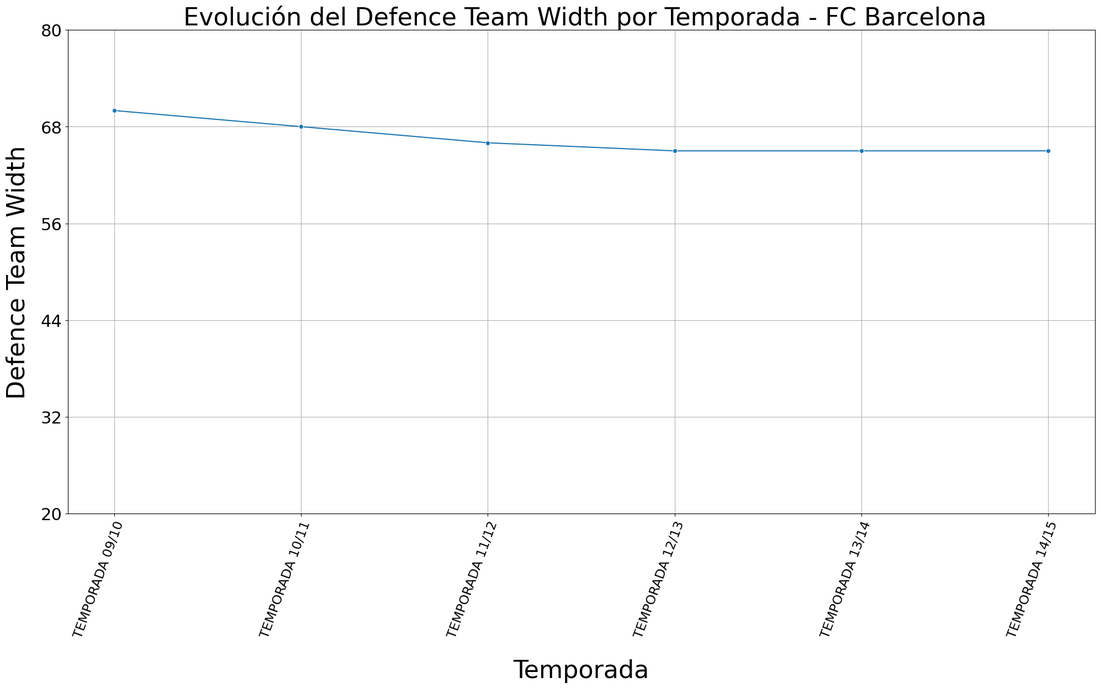

In [47]:
df_dtw = df_f[['team_long_name','DTW-TEMPORADA 09/10',	'DTW-TEMPORADA 10/11',	'DTW-TEMPORADA 11/12',	'DTW-TEMPORADA 12/13',	'DTW-TEMPORADA 13/14',	'DTW-TEMPORADA 14/15']]

# Escoger de que equipo hacer el gráfico
equipo_especifico = "FC Barcelona"
df_dtw = df_f[['team_long_name', 'DTW-TEMPORADA 09/10', 'DTW-TEMPORADA 10/11', 'DTW-TEMPORADA 11/12',
                 'DTW-TEMPORADA 12/13', 'DTW-TEMPORADA 13/14', 'DTW-TEMPORADA 14/15']]

df_dtw= df_dtw[df_dtw["team_long_name"] == equipo_especifico]  # Filtra solo un equipo

# Suponiendo que df_f tiene equipos como filas y años como columnas
# Convertir el DataFrame a formato largo
df_dtw2 = df_dtw.melt(id_vars=["team_long_name"], var_name="Temporada", value_name="Valor") #["team_long_name"]

# Crear el gráfico de líneas
plt.figure(figsize=(24, 12))
dtw = sns.lineplot(data=df_dtw2, x="Temporada", y="Valor", marker="o")

# Personalizar gráfico
plt.xlabel("Temporada",fontsize=32,labelpad = 25)
plt.ylabel("Defence Team Width",fontsize=32,labelpad = 15)


# ESTO SOLO PARA LOS GRÁFICOS NUMÉRICOS, PARA LOS DE PALABRAS ELIMINAR TODO MENOS EL INVERT
#Toquetear el eje y
#dtw.invert_yaxis()
# Definir rango del eje Y
plt.ylim(20, 80)

# Número de divisiones deseado
num_divisiones = 6  

# Generar los valores de las marcas (ticks)
yticks = np.linspace(20, 80, num_divisiones)  

# Aplicar las marcas al eje Y
plt.yticks(yticks)

plt.title(" Evolución del Defence Team Width por Temporada - FC Barcelona",fontsize=32)
# plt.legend(title="Equipos",fontsize=25,title_fontsize=54, loc="center left", bbox_to_anchor=(-0.24,0.5),borderaxespad=0.)

plt.xticks(fontsize=17,rotation=70,ha = 'right',rotation_mode='anchor') # Rotar etiquetas si hay muchos años
nombres_personalizados = ["TEMPORADA 09/10", "TEMPORADA 10/11", "TEMPORADA 11/12", "TEMPORADA 12/13", "TEMPORADA 13/14", "TEMPORADA 14/15"]
plt.xticks(ticks=range(len(nombres_personalizados)), labels=nombres_personalizados)

plt.yticks(fontsize=22,rotation=0)
plt.subplots_adjust(bottom=0.15)
#plt.margins(x=0.4)
#plt.subplots_adjust(left=0.05, right=0.75)
plt.grid(True)

### GRÁFICO FUSIONADO DEFENSA

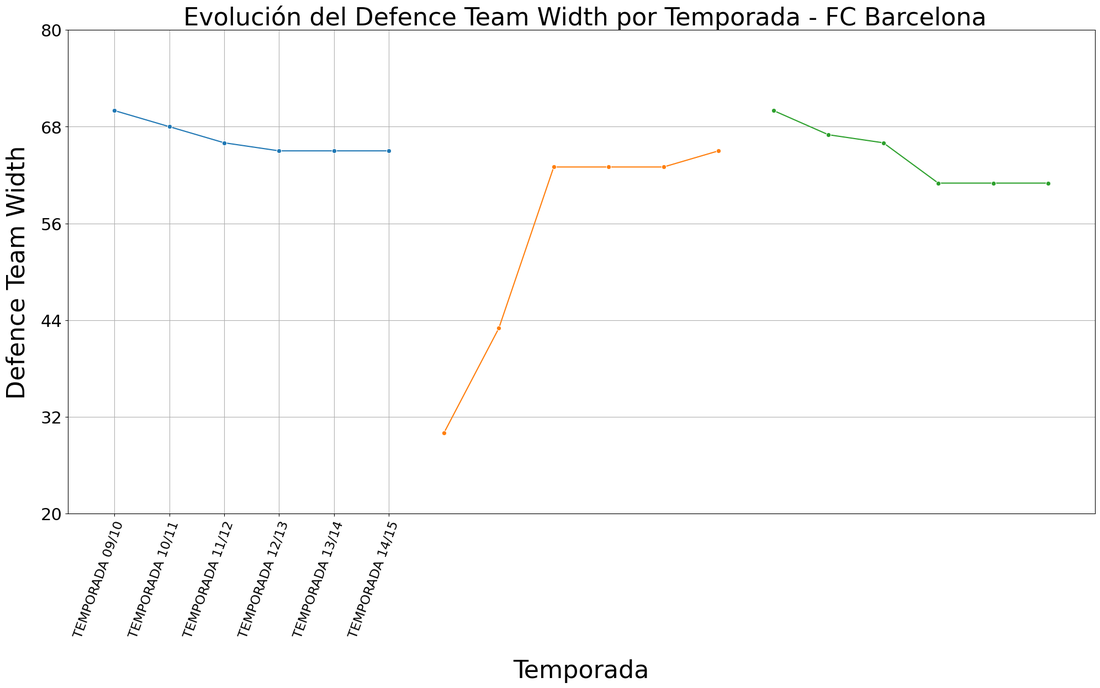

In [49]:
df_dtw = df_f[['team_long_name','DTW-TEMPORADA 09/10',	'DTW-TEMPORADA 10/11',	'DTW-TEMPORADA 11/12',	'DTW-TEMPORADA 12/13',	'DTW-TEMPORADA 13/14',	'DTW-TEMPORADA 14/15']]

# Escoger de que equipo hacer el gráfico
equipo_especifico = "FC Barcelona"
df_dtw = df_f[['team_long_name', 'DTW-TEMPORADA 09/10', 'DTW-TEMPORADA 10/11', 'DTW-TEMPORADA 11/12',
                 'DTW-TEMPORADA 12/13', 'DTW-TEMPORADA 13/14', 'DTW-TEMPORADA 14/15']]

df_dtw= df_dtw[df_dtw["team_long_name"] == equipo_especifico]  # Filtra solo un equipo

# Suponiendo que df_f tiene equipos como filas y años como columnas
# Convertir el DataFrame a formato largo
df_dtw2 = df_dtw.melt(id_vars=["team_long_name"], var_name="Temporada", value_name="Valor") #["team_long_name"]

# Crear el gráfico de líneas
plt.figure(figsize=(24, 12))
dtw = sns.lineplot(data=df_dtw2, x="Temporada", y="Valor", marker="o")
da = sns.lineplot(data=df_da2, x="Temporada", y="Valor", marker="o")
dp = sns.lineplot(data=df_dp2, x="Temporada", y="Valor", marker="o")

# Personalizar gráfico
plt.xlabel("Temporada",fontsize=32,labelpad = 25)
plt.ylabel("Defence Team Width",fontsize=32,labelpad = 15)


# ESTO SOLO PARA LOS GRÁFICOS NUMÉRICOS, PARA LOS DE PALABRAS ELIMINAR TODO MENOS EL INVERT
#Toquetear el eje y
#dtw.invert_yaxis()
# Definir rango del eje Y
plt.ylim(20, 80)

# Número de divisiones deseado
num_divisiones = 6  

# Generar los valores de las marcas (ticks)
yticks = np.linspace(20, 80, num_divisiones)  

# Aplicar las marcas al eje Y
plt.yticks(yticks)

plt.title(" Evolución del Defence Team Width por Temporada - FC Barcelona",fontsize=32)
# plt.legend(title="Equipos",fontsize=25,title_fontsize=54, loc="center left", bbox_to_anchor=(-0.24,0.5),borderaxespad=0.)

plt.xticks(fontsize=17,rotation=70,ha = 'right',rotation_mode='anchor') # Rotar etiquetas si hay muchos años
nombres_personalizados = ["TEMPORADA 09/10", "TEMPORADA 10/11", "TEMPORADA 11/12", "TEMPORADA 12/13", "TEMPORADA 13/14", "TEMPORADA 14/15"]
plt.xticks(ticks=range(len(nombres_personalizados)), labels=nombres_personalizados)

plt.yticks(fontsize=22,rotation=0)
plt.subplots_adjust(bottom=0.15)
#plt.margins(x=0.4)
#plt.subplots_adjust(left=0.05, right=0.75)
plt.grid(True)

# SPARKLINES

### CÓDIGO PARA CREAR TABLA DE SPARKLINES Y MODIFICARLA A GUSTO PERSONAL

FC BARCELONA,SPARKLINE
Build Up Play Speed,
Build Up Play Dribbling,
Build Up Play Passing,
Chance Creation Passing,
Chance Creation Crossing,
Chance Creation Shooting,
Defence Pressure,
Defence Aggression,
Defence Team Width,

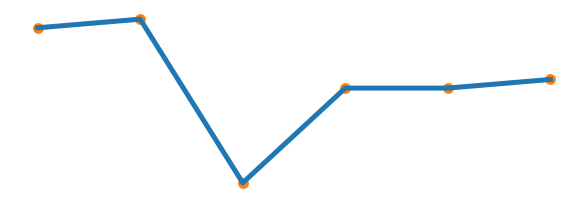
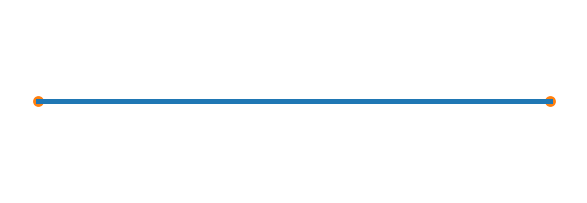
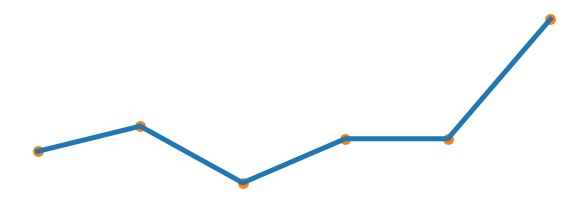
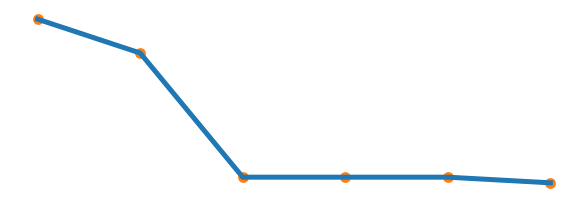
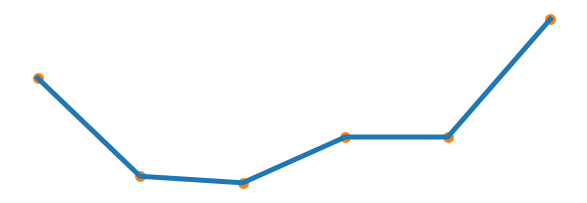
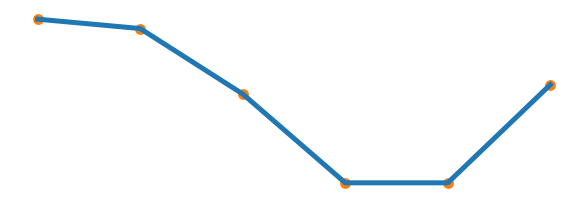
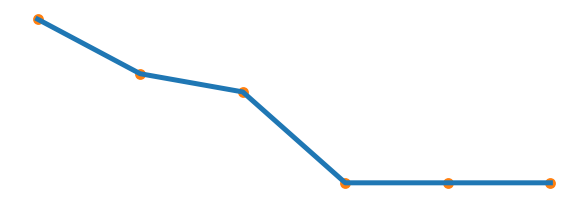
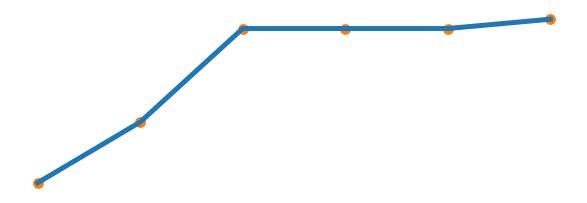
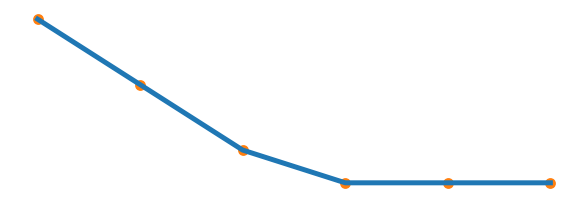

In [52]:
CONFIG = {
    "sparkline_size": (5.0, 1.8),  # Tamaño aumentado
    "line_color": "#1f77b4",
    "line_width": 3,
    "dot_color": "#ff7f0e",
    "dot_size": 30,
    "bg_color": "none",
    "font_size": "16px",
    "table_style": {
        "width": "95%",
        "header_bg": "#2C3E50",
        "header_text": "white",
        "cell_padding": "12px"
    }
}

#SPARKLINES

def create_sparkline(data, years):
    """Genera sparklines sin información de promedio"""
    try:
        fig, ax = plt.subplots(figsize=CONFIG["sparkline_size"])
        fig.patch.set_alpha(0.0)  # Fondo transparente
        
        # Filtrar datos válidos
        valid_data = [y for y in data if pd.notna(y)]
        valid_years = [years[i] for i, y in enumerate(data) if pd.notna(y)]
        
        if valid_data:
            ax.plot(valid_years, valid_data, 
                   color=CONFIG["line_color"], 
                   linewidth=CONFIG["line_width"])
            ax.scatter(valid_years, valid_data, 
                      color=CONFIG["dot_color"], 
                      s=CONFIG["dot_size"])
        
        ax.axis('off')
        plt.tight_layout()
        
        buf = BytesIO()
        plt.savefig(buf, format='png', bbox_inches='tight', dpi=120)
        plt.close(fig)
        return base64.b64encode(buf.getvalue()).decode('utf-8')
    
    except Exception as e:
        print(f"⚠️ Error: {str(e)}")
        return None

#FUNCIÓN PRINCIPAL

l = df_f[['buildUpPlaySpeed', 'buildUpPlayDribbling', 'buildUpPlayPassing', 'chanceCreationPassing', 'chanceCreationCrossing', 'chanceCreationShooting', 'defencePressure', 'defenceAggression', 'defenceTeamWidth' ]]
def generate_team_report(df, team_name, years):
    """Genera reporte solo con sparklines"""
    try:
        team_data = df[df['team_long_name'] == team_name].iloc[0]
        metrics = [col for col in l.columns if isinstance(team_data[col], (list, np.ndarray))]

        html = f"""
        <style>
            .report-table {{
                width: {CONFIG["table_style"]["width"]};
                max-width: 1600px;  /* Ancho máximo */
                line-height: 1.2;
                font-size: {CONFIG["font_size"]};
                border-collapse: collapse;
                margin: 20px auto;
                font-family: Arial;
            }}
            .report-table th {{
                background-color: {CONFIG["table_style"]["header_bg"]};
                color: {CONFIG["table_style"]["header_text"]};
                padding: {CONFIG["table_style"]["cell_padding"]};
                text-align: center;
                font-size: 40px;
            }}
            .report-table td {{
                padding: {CONFIG["table_style"]["cell_padding"]};
                border-bottom: 1px solid #ddd;
                text-align: center;
                font-size: 38px;
            }}
            .report-table th:nth-child(1) {{ width: 30%; }}  # Columna 1 más estrecha
            .report-table th:nth-child(2) {{ width: 60%; }}  # Columna 2 más ancha
            .report-table td {{
                padding: {CONFIG["table_style"]["cell_padding"]};
                border-bottom: 1px solid #ddd;
                text-align: center;
            }}
        </style>
        <table class='report-table'>
            <thead>
                <tr>
                    <th>FC BARCELONA</th>
                    <th>SPARKLINE</th>
                </tr>
            </thead>
            <tbody>
        """
        def format_metric_name(metric_name):
            import re
            # Separa las palabras en mayúsculas y añade espacios
            formatted = re.sub(r'(?<=[a-z])(?=[A-Z])', ' ', metric_name)
            # Capitaliza la primera letra de cada palabra
            return formatted.title()

        for metric in metrics:
            sparkline_b64 = create_sparkline(team_data[metric], years)
            sparkline_html = f'<img src="data:image/png;base64,{sparkline_b64}">' if sparkline_b64 else "❌ Error"
            metric_display = format_metric_name(metric)
            html += f"""
            <tr>
               <td class='metric-name'>{metric_display}</td>
               <td class='sparkline-cell'>{sparkline_html}</td>
            </tr>
            """
        
        html += "</tbody></table>"
        return HTML(html)
    
    except Exception as e:
        return HTML("<p style='color:red'>Error al generar el reporte</p>")

# RUNEADO
YEARS = ['09/10', '10/11', '11/12', '12/13', '13/14', '14/15']  # Tus años personalizados
TEAM = "FC Barcelona"  # Cambia al equipo que necesites

report = generate_team_report(df_f, TEAM, YEARS)
display(report)
with open("table.html", "w") as f:
    f.write(generate_team_report(df_f, "FC Barcelona", YEARS).data)
    

REAL MADRID CF,SPARKLINE
Build Up Play Speed,
Build Up Play Dribbling,
Build Up Play Passing,
Chance Creation Passing,
Chance Creation Crossing,
Chance Creation Shooting,
Defence Pressure,
Defence Aggression,
Defence Team Width,

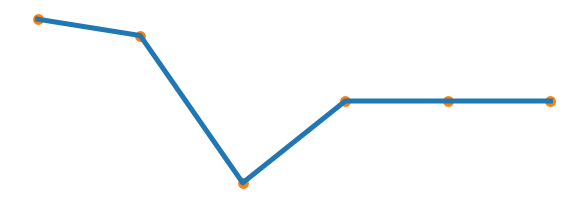
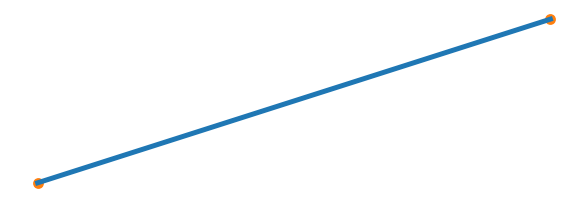
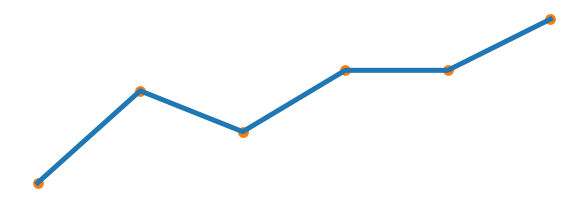
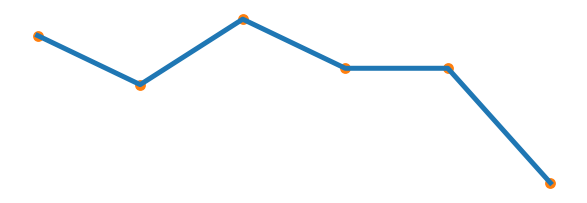
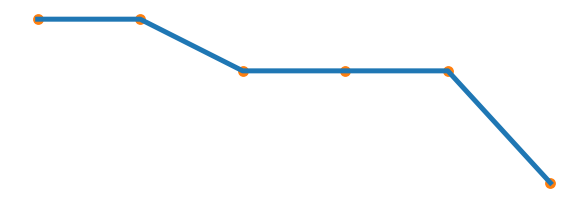
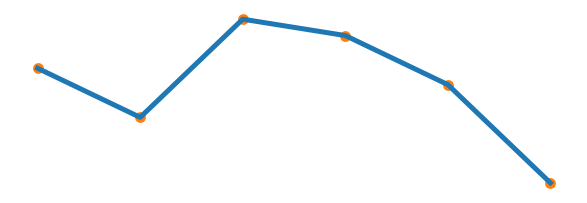
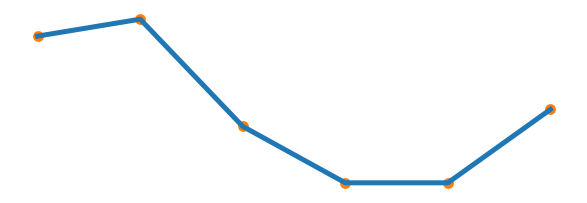
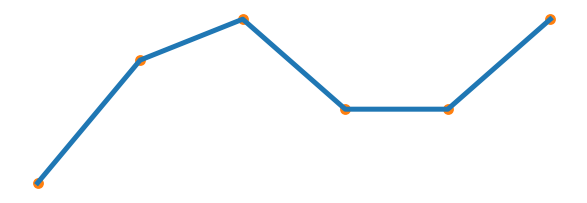
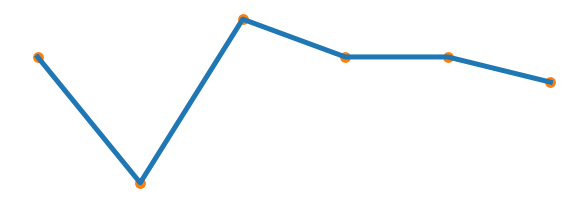

In [53]:
CONFIG = {
    "sparkline_size": (5.0, 1.8),  # Tamaño aumentado
    "line_color": "#1f77b4",
    "line_width": 3,
    "dot_color": "#ff7f0e",
    "dot_size": 30,
    "bg_color": "none",
    "font_size": "16px",
    "table_style": {
        "width": "95%",
        "header_bg": "#2C3E50",
        "header_text": "white",
        "cell_padding": "12px"
    }
}

#SPARKLINES

def create_sparkline(data, years):
    """Genera sparklines sin información de promedio"""
    try:
        fig, ax = plt.subplots(figsize=CONFIG["sparkline_size"])
        fig.patch.set_alpha(0.0)  # Fondo transparente
        
        # Filtrar datos válidos
        valid_data = [y for y in data if pd.notna(y)]
        valid_years = [years[i] for i, y in enumerate(data) if pd.notna(y)]
        
        if valid_data:
            ax.plot(valid_years, valid_data, 
                   color=CONFIG["line_color"], 
                   linewidth=CONFIG["line_width"])
            ax.scatter(valid_years, valid_data, 
                      color=CONFIG["dot_color"], 
                      s=CONFIG["dot_size"])
        
        ax.axis('off')
        plt.tight_layout()
        
        buf = BytesIO()
        plt.savefig(buf, format='png', bbox_inches='tight', dpi=120)
        plt.close(fig)
        return base64.b64encode(buf.getvalue()).decode('utf-8')
    
    except Exception as e:
        print(f"⚠️ Error: {str(e)}")
        return None

#FUNCIÓN PRINCIPAL

l = df_f[['buildUpPlaySpeed', 'buildUpPlayDribbling', 'buildUpPlayPassing', 'chanceCreationPassing', 'chanceCreationCrossing', 'chanceCreationShooting', 'defencePressure', 'defenceAggression', 'defenceTeamWidth' ]]
def generate_team_report(df, team_name, years):
    """Genera reporte solo con sparklines"""
    try:
        team_data = df[df['team_long_name'] == team_name].iloc[0]
        metrics = [col for col in l.columns if isinstance(team_data[col], (list, np.ndarray))]

        html = f"""
        <style>
            .report-table {{
                width: {CONFIG["table_style"]["width"]};
                max-width: 1600px;  /* Ancho máximo */
                line-height: 1.2;
                font-size: {CONFIG["font_size"]};
                border-collapse: collapse;
                margin: 20px auto;
                font-family: Arial;
            }}
            .report-table th {{
                background-color: {CONFIG["table_style"]["header_bg"]};
                color: {CONFIG["table_style"]["header_text"]};
                padding: {CONFIG["table_style"]["cell_padding"]};
                text-align: center;
                font-size: 40px;
            }}
            .report-table td {{
                padding: {CONFIG["table_style"]["cell_padding"]};
                border-bottom: 1px solid #ddd;
                text-align: center;
                font-size: 38px;
            }}
            .report-table th:nth-child(1) {{ width: 30%; }}  # Columna 1 más estrecha
            .report-table th:nth-child(2) {{ width: 60%; }}  # Columna 2 más ancha
            .report-table td {{
                padding: {CONFIG["table_style"]["cell_padding"]};
                border-bottom: 1px solid #ddd;
                text-align: center;
            }}
        </style>
        <table class='report-table'>
            <thead>
                <tr>
                    <th>REAL MADRID CF</th>
                    <th>SPARKLINE</th>
                </tr>
            </thead>
            <tbody>
        """
        def format_metric_name(metric_name):
            import re
            # Separa las palabras en mayúsculas y añade espacios
            formatted = re.sub(r'(?<=[a-z])(?=[A-Z])', ' ', metric_name)
            # Capitaliza la primera letra de cada palabra
            return formatted.title()

        for metric in metrics:
            sparkline_b64 = create_sparkline(team_data[metric], years)
            sparkline_html = f'<img src="data:image/png;base64,{sparkline_b64}">' if sparkline_b64 else "❌ Error"
            metric_display = format_metric_name(metric)
            html += f"""
            <tr>
               <td class='metric-name'>{metric_display}</td>
               <td class='sparkline-cell'>{sparkline_html}</td>
            </tr>
            """
        
        html += "</tbody></table>"
        return HTML(html)
    
    except Exception as e:
        return HTML("<p style='color:red'>Error al generar el reporte</p>")

# RUNEADO
YEARS = ['09/10', '10/11', '11/12', '12/13', '13/14', '14/15']  # Tus años personalizados
TEAM = "Real Madrid CF"  # Cambia al equipo que necesites

report = generate_team_report(df_f, TEAM, YEARS)
display(report)
with open("table.html", "w") as f:
    f.write(generate_team_report(df_f, "Real Madrid CF", YEARS).data)
    

ATLÉTICO DE MADRID,SPARKLINE
Build Up Play Speed,
Build Up Play Dribbling,
Build Up Play Passing,
Chance Creation Passing,
Chance Creation Crossing,
Chance Creation Shooting,
Defence Pressure,
Defence Aggression,
Defence Team Width,

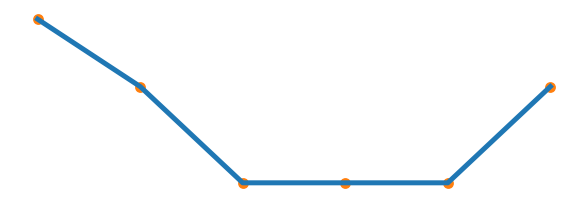
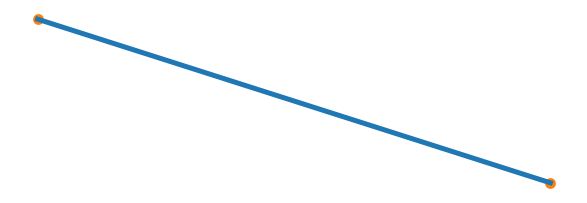
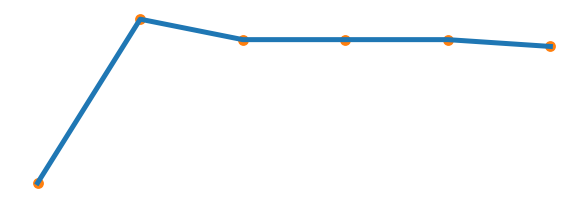
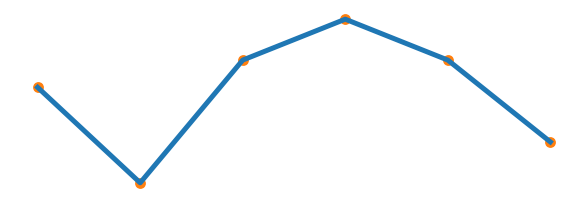
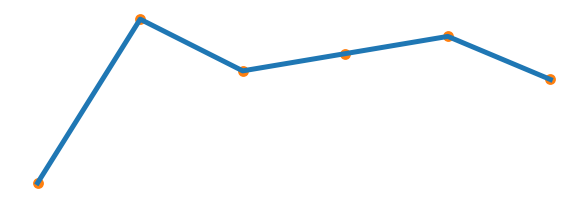
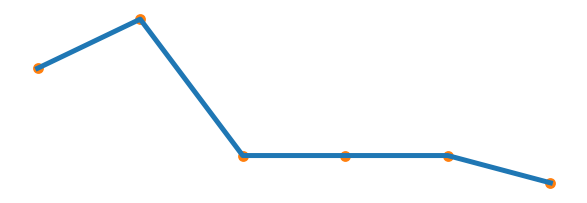
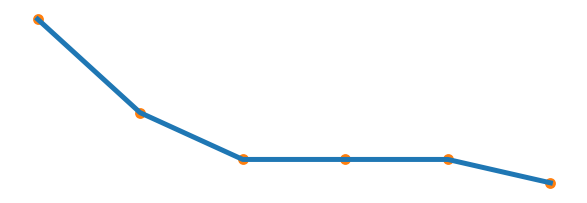
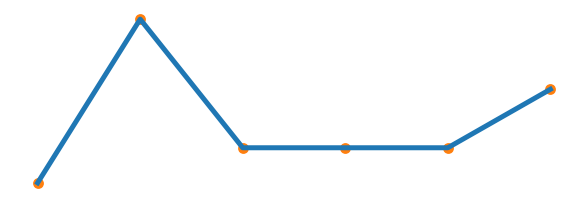
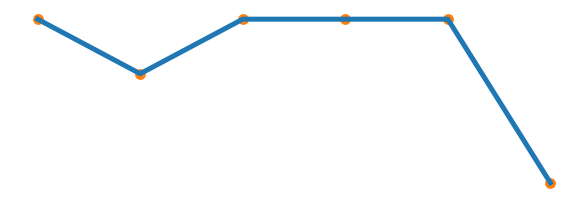

In [54]:
CONFIG = {
    "sparkline_size": (5.0, 1.8),  # Tamaño aumentado
    "line_color": "#1f77b4",
    "line_width": 3,
    "dot_color": "#ff7f0e",
    "dot_size": 30,
    "bg_color": "none",
    "font_size": "16px",
    "table_style": {
        "width": "95%",
        "header_bg": "#2C3E50",
        "header_text": "white",
        "cell_padding": "12px"
    }
}

#SPARKLINES

def create_sparkline(data, years):
    """Genera sparklines sin información de promedio"""
    try:
        fig, ax = plt.subplots(figsize=CONFIG["sparkline_size"])
        fig.patch.set_alpha(0.0)  # Fondo transparente
        
        # Filtrar datos válidos
        valid_data = [y for y in data if pd.notna(y)]
        valid_years = [years[i] for i, y in enumerate(data) if pd.notna(y)]
        
        if valid_data:
            ax.plot(valid_years, valid_data, 
                   color=CONFIG["line_color"], 
                   linewidth=CONFIG["line_width"])
            ax.scatter(valid_years, valid_data, 
                      color=CONFIG["dot_color"], 
                      s=CONFIG["dot_size"])
        
        ax.axis('off')
        plt.tight_layout()
        
        buf = BytesIO()
        plt.savefig(buf, format='png', bbox_inches='tight', dpi=120)
        plt.close(fig)
        return base64.b64encode(buf.getvalue()).decode('utf-8')
    
    except Exception as e:
        print(f"⚠️ Error: {str(e)}")
        return None

#FUNCIÓN PRINCIPAL

l = df_f[['buildUpPlaySpeed', 'buildUpPlayDribbling', 'buildUpPlayPassing', 'chanceCreationPassing', 'chanceCreationCrossing', 'chanceCreationShooting', 'defencePressure', 'defenceAggression', 'defenceTeamWidth' ]]
def generate_team_report(df, team_name, years):
    """Genera reporte solo con sparklines"""
    try:
        team_data = df[df['team_long_name'] == team_name].iloc[0]
        metrics = [col for col in l.columns if isinstance(team_data[col], (list, np.ndarray))]

        html = f"""
        <style>
            .report-table {{
                width: {CONFIG["table_style"]["width"]};
                max-width: 1600px;  /* Ancho máximo */
                line-height: 1.2;
                font-size: {CONFIG["font_size"]};
                border-collapse: collapse;
                margin: 20px auto;
                font-family: Arial;
            }}
            .report-table th {{
                background-color: {CONFIG["table_style"]["header_bg"]};
                color: {CONFIG["table_style"]["header_text"]};
                padding: {CONFIG["table_style"]["cell_padding"]};
                text-align: center;
                font-size: 40px;
            }}
            .report-table td {{
                padding: {CONFIG["table_style"]["cell_padding"]};
                border-bottom: 1px solid #ddd;
                text-align: center;
                font-size: 38px;
            }}
            .report-table th:nth-child(1) {{ width: 30%; }}  # Columna 1 más estrecha
            .report-table th:nth-child(2) {{ width: 60%; }}  # Columna 2 más ancha
            .report-table td {{
                padding: {CONFIG["table_style"]["cell_padding"]};
                border-bottom: 1px solid #ddd;
                text-align: center;
            }}
        </style>
        <table class='report-table'>
            <thead>
                <tr>
                    <th>ATLÉTICO DE MADRID</th>
                    <th>SPARKLINE</th>
                </tr>
            </thead>
            <tbody>
        """
        def format_metric_name(metric_name):
            import re
            # Separa las palabras en mayúsculas y añade espacios
            formatted = re.sub(r'(?<=[a-z])(?=[A-Z])', ' ', metric_name)
            # Capitaliza la primera letra de cada palabra
            return formatted.title()

        for metric in metrics:
            sparkline_b64 = create_sparkline(team_data[metric], years)
            sparkline_html = f'<img src="data:image/png;base64,{sparkline_b64}">' if sparkline_b64 else "❌ Error"
            metric_display = format_metric_name(metric)
            html += f"""
            <tr>
               <td class='metric-name'>{metric_display}</td>
               <td class='sparkline-cell'>{sparkline_html}</td>
            </tr>
            """
        
        html += "</tbody></table>"
        return HTML(html)
    
    except Exception as e:
        return HTML("<p style='color:red'>Error al generar el reporte</p>")

# RUNEADO
YEARS = ['09/10', '10/11', '11/12', '12/13', '13/14', '14/15']  # Tus años personalizados
TEAM = "Atlético Madrid"  # Cambia al equipo que necesites

report = generate_team_report(df_f, TEAM, YEARS)
display(report)
with open("table.html", "w") as f:
    f.write(generate_team_report(df_f, "Atlético Madrid", YEARS).data)
    